# 1.Reddit GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD REDDIT GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/reddit_graph.csv"
)

print("=" * 60)
print("REDDIT_GRAPH DATA")
print("=" * 60)

print(df.shape)

REDDIT_GRAPH DATA
(37585, 30)


In [2]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# Giả sử 'df' là DataFrame chứa dữ liệu Reddit của bà
# =====================================================
# 1. GENERATE NODES
# =====================================================
print("Đang tạo Nodes cho Reddit...")
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]

# Xuất file Node
nodes_df.to_csv("reddit_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (REDDIT COMMUNITY & ENGAGEMENT)
# =====================================================
edges_list = []

# Sắp xếp theo followers (Trên Reddit thường là Karma hoặc Subreddit size)
# Vì nó chiếm tới 22% importance nên ta dùng nó làm trục xương sống
sorted_df = df.sort_values(by=['followers'], ascending=True)

# --- A. CÁC CỘT CHỦ ĐỀ VÀ NGÔN NGỮ (TOPIC & LANGUAGE) ---
# Dựa trên Top Feature: Gaming, Education, Food, Entertainment
# Và các ngôn ngữ mạnh: Japanese, Korean, Portuguese
cat_features = ['topic', 'language']

for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Reddit Interest Homophily: {feat}...")
    
    for val, group in sorted_df.groupby(feat):
        if pd.isna(val): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            # Tăng trọng số cho Gaming và Education (Top 5 importance)
            weight = 1.5 if val in ['Gaming', 'Education'] else 1.2
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": feat
            })

# --- B. ĐẶC TRƯNG CUỐI TUẦN (WEEKEND VIBE - MỚI) ---
# Vì is_weekend lọt vào Top 10 của Reddit
if 'is_weekend' in sorted_df.columns:
    print("Processing Weekend Engagement Homophily...")
    # Nối các bài post cùng đăng vào cuối tuần để xem "vibe" nghỉ ngơi
    weekend_group = sorted_df[sorted_df['is_weekend'] == 1]
    ids = weekend_group['post_id'].values
    
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.0, 
                "Relation": "weekend_connection"
            })

# --- C. LOẠI HÌNH BÌNH CHỌN (MEDIA TYPE POLL) ---
# Vì media_type_Poll rất mạnh trên Reddit
if 'media_type' in sorted_df.columns:
    print("Processing Reddit Poll Interaction...")
    poll_group = sorted_df[sorted_df['media_type'] == 'Poll']
    ids = poll_group['post_id'].values
    
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.3, # Polls kéo người dùng vào thảo luận cùng nhau
                "Relation": "poll_homophily"
            })

# --- D. ĐỘ TOXIC VÀ CẢM XÚC (TOXICITY & NEGATIVE SENTIMENT) ---
# Toxicity_score và Sentiment_negative đều nằm trong Top 15
if 'toxicity_score' in sorted_df.columns:
    print("Processing Reddit Debate & Toxicity Vibe...")
    temp_df = sorted_df.copy()
    # Reddit thường có các subreddits rất "gắt", ta gom nhóm theo độ toxic
    temp_df['toxic_bins'] = temp_df['toxicity_score'].apply(lambda x: round(x/10)*10)
    
    for val, group in temp_df.groupby('toxic_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.8, 
                "Relation": "toxicity_cluster"
            })

# --- E. QUAN HỆ TÁC GIẢ (USER-ID) ---
print("Processing Reddit User Posting History...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.0, # Người dùng Reddit thường trung thành với 1 vài Subreddit
                "Relation": "same_author"
            })

# =====================================================
# 3. CLEAN & EXPORT
# =====================================================
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("reddit_edge.csv", index=False, encoding='utf-8')

print(f"\n--- THÀNH PHẨM REDDIT GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Đang tạo Nodes cho Reddit...
Processing Reddit Interest Homophily: topic...
Processing Reddit Interest Homophily: language...
Processing Weekend Engagement Homophily...
Processing Reddit Poll Interaction...
Processing Reddit Debate & Toxicity Vibe...
Processing Reddit User Posting History...

--- THÀNH PHẨM REDDIT GRAPH ---
Nodes: 37,585
Edges: 126,417
Time: 3.88s


In [293]:
import pandas as pd

graph_df = pd.read_csv(
    "reddit-result-12.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(37585, 45)

Columns:
['Id', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Weighted Degree', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'componentnumber', 'modularity_class', 'stat_inf_class', 'clustering', 'triangles', 'eigencentrality']


In [294]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    "Id",
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "clustering",
    "modularity_class"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(37585, 6)


In [295]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [296]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [297]:
# LOAD REDDIT TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (30068, 56)
Test Shape : (7517, 56)


In [298]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [299]:
# --- CODE XEM GIÁ TRỊ POPULARITY TẠI ĐÂY ---
print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TRAIN")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TEST")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    23931
1     6137
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.589597
1    20.410403
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    5983
1    1534
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.592923
1    20.407077
Name: proportion, dtype: float64


In [300]:
# 1. Tính TỰ ĐỘNG tỷ lệ Ratio dựa trên tập Train
# Công thức chuẩn của XGBoost: sum(negative instances) / sum(positive instances)
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Đã kích hoạt chống lười! Trọng số scale_pos_weight = {ratio:.2f}")

Đã kích hoạt chống lười! Trọng số scale_pos_weight = 3.90


In [301]:
# FILL MISSING VALUES (BẢN NÂNG CẤP THEO BỘ FEATURE MỚI)
# =====================================================

# 1. Cập nhật đầy đủ các chỉ số đo lường (Numerical)
# Thêm các cột mới mà mình vừa trích xuất từ đồ thị "sợi xích"
numeric_graph_cols = [
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "clustering"
]

# Lọc lại những cột thực sự tồn tại trong dataset để tránh lỗi
existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

if "modularity_class" in train_hybrid.columns:
    train_hybrid["modularity_class"] = train_hybrid["modularity_class"].fillna(-1)
    test_hybrid["modularity_class"]  = test_hybrid["modularity_class"].fillna(-1)

# Điền 0: Hợp lý vì nếu bài post không có kết nối thì các chỉ số uy tín = 0
train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("\n" + "=" * 60)
print("HYBRID DATASETS - CLEANED & ALIGNED")
print("=" * 60)
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")


HYBRID DATASETS - CLEANED & ALIGNED
Train Hybrid: (30068, 61)
Test Hybrid : (7517, 61)


In [302]:
# =====================================================
# 1. XỬ LÝ MODULARITY TRƯỚC KHI ONE-HOT (TRÊN TẬP HYBRID)
# =====================================================
for df_tmp in [train_hybrid, test_hybrid]:
    if "modularity_class" in df_tmp.columns:
        # Bước quan trọng: Ép sang string để Pandas hiểu đây là Category
        # Tui thêm chữ 'comm_' để sau này bảng Importance nhìn cho Pro
        df_tmp["modularity_class"] = "comm_" + df_tmp["modularity_class"].astype(str)

# =====================================================
# 2. CHẠY ONE-HOT ĐỒNG BỘ CHO CẢ TRAIN VÀ TEST
# =====================================================
categorical_cols = ["topic", "language", "media_type", "sentiment_category", "location", "modularity_class"]

# Tìm những cột thực sự đang có mặt trong tập Train
existing_cats = [col for col in categorical_cols if col in train_hybrid.columns]

# Chạy get_dummies cho cả hai
train_hybrid = pd.get_dummies(train_hybrid, columns=existing_cats, drop_first=True, dtype=int)
test_hybrid = pd.get_dummies(test_hybrid, columns=existing_cats, drop_first=True, dtype=int)

# =====================================================
# 3. CĂN CHỈNH CỘT (CỰC KỲ QUAN TRỌNG)
# =====================================================
# Đảm bảo tập Test có đầy đủ các cột như tập Train (tránh lỗi khi Predict)
train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=train_cols, fill_value=0)

print(f"✅ Đã One-hot xong! Cột 'modularity_class' đã biến mất và thay bằng các cột 'comm_x'.")
print(f"Số lượng feature hiện tại: {train_hybrid.shape[1]}")

✅ Đã One-hot xong! Cột 'modularity_class' đã biến mất và thay bằng các cột 'comm_x'.
Số lượng feature hiện tại: 116


In [303]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "reddit_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "reddit_hybrid_test.csv",
    index=False
)

In [304]:
# =====================================================
# INSTAGRAM HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [305]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "reddit_hybrid_train.csv"
)

test_df = pd.read_csv(
    "reddit_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (30068, 116)
Test Shape : (7517, 116)


In [306]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [307]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (30068, 113)
X_test Shape : (7517, 113)


In [336]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.7,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [337]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [338]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [340]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [341]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      5983
           1       0.44      0.76      0.56      1534

    accuracy                           0.75      7517
   macro avg       0.68      0.75      0.69      7517
weighted avg       0.82      0.75      0.77      7517

ROC-AUC  : 0.8418


In [342]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[4495 1488]
 [ 372 1162]]


In [343]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                      feature  importance
82   modularity_class_comm_32    0.077499
66   modularity_class_comm_18    0.069806
67   modularity_class_comm_19    0.069714
3                   followers    0.069484
77   modularity_class_comm_28    0.061181
84   modularity_class_comm_34    0.049679
109   modularity_class_comm_6    0.047851
96   modularity_class_comm_45    0.043890
73   modularity_class_comm_24    0.036091
86   modularity_class_comm_36    0.028000
88   modularity_class_comm_38    0.017073
63   modularity_class_comm_15    0.016505
61   modularity_class_comm_13    0.012346
107  modularity_class_comm_55    0.010743
97   modularity_class_comm_46    0.008154
58   modularity_class_comm_10    0.007609
98   modularity_class_comm_47    0.005746
65   modularity_class_comm_17    0.005559
93   modularity_class_comm_42    0.005098
108  modularity_class_comm_56    0.005077


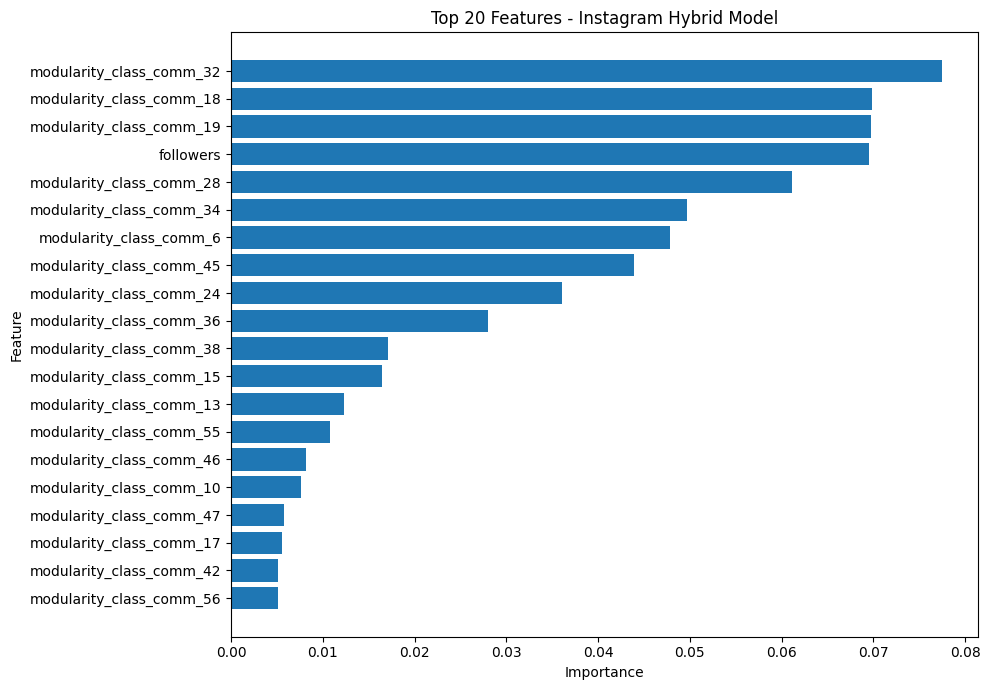

In [344]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Instagram Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. INSTAGRAM NODE2VEC

 GRAPH EMBEDDING

In [94]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()

# 1. CHỈ CẦN NẠP EDGES LÀ ĐỦ
# =====================================================
print("Đang nạp file Edges...")
edges_df = pd.read_csv("reddit_edge.csv") # Đổi tên file cho đúng với của bạn nhé

# 2. XÂY DỰNG GRAPH SIÊU TỐC TRONG 1 GIÂY (Không dùng iterrows)
# =====================================================
print("Đang xây dựng NetworkX Graph...")
# Hàm này của NetworkX tự động nạp toàn bộ edges và sinh ra Nodes cực nhanh
G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() # Đảm bảo là Đồ thị vô hướng (Undirected)
)

print(f"Graph Created 🚀 | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")

# 3. CHẠY NODE2VEC (TỐI ƯU TỐC ĐỘ VÀ CHỐNG OVERFITTING)
# =====================================================
print("TRAINING NODE2VEC (MULTI-CORE)...")


# 1. Tự động đếm số lượng lõi CPU trên máy của bà
so_loi_cpu = os.cpu_count()
print(f"👉 Máy của bà đang có {so_loi_cpu} lõi CPU. Đang huy động toàn bộ...")

print("\n" + "=" * 60)
print("TRAINING NODE2VEC (MULTI-CORE CẬP NHẬT)...")
print("=" * 60)



Đang nạp file Edges...
Đang xây dựng NetworkX Graph...
Graph Created 🚀 | Nodes: 37,585 | Edges: 116,157
TRAINING NODE2VEC (MULTI-CORE)...
👉 Máy của bà đang có 22 lõi CPU. Đang huy động toàn bộ...

TRAINING NODE2VEC (MULTI-CORE CẬP NHẬT)...


In [95]:
from node2vec import Node2Vec
import time
# 2. Truyền con số dương vào tham số workers
node2vec = Node2Vec(
    G,
    dimensions=8,        # Giữ nguyên 8 chiều để XGBoost không ngộp
    walk_length=10,      
    num_walks=20,        
    workers=so_loi_cpu,  # <--- BÍ KÍP ĐÃ ĐƯỢC SỬA Ở ĐÂY
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec hoàn thành 🚀")

print(f"\nNode2Vec hoàn thành sau: {round((time.time() - start_time)/60, 2)} phút 🚀")



Computing transition probabilities:   0%|          | 0/37585 [00:00<?, ?it/s]


Node2Vec hoàn thành 🚀

Node2Vec hoàn thành sau: 8.78 phút 🚀


In [101]:
# 4. TRÍCH XUẤT VÀ LƯU VECTOR RA FILE CSV ĐỂ MERGE
# =====================================================
print("Đang xuất Embeddings ra DataFrame...")

# Trích xuất ID của Node và 8 cột Vector
node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

# Tạo DataFrame
emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids # Cột này cực kỳ quan trọng để lát nữa merge với tập Train/Test

# LỌC BỎ CÁC TRẠM HUBS (TOPIC, LANG...):
# Vì trong danh sách node có cả "TOPIC_Sports", ta chỉ lấy những dòng có dạng "INS..." (là bài Post)
emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('RED')]

# Lưu ra file CSV
emb_df.to_csv("reddit_node2vec_8dims.csv", index=False)
print(f"Đã lưu thành công {len(emb_df)} vectors của bài Post!")

Đang xuất Embeddings ra DataFrame...
Đã lưu thành công 37585 vectors của bài Post!


In [156]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [157]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (30068, 56)
Test Shape : (7517, 56)


In [345]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "reddit_node2vec_8dims.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(37585, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [159]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [160]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (30068, 61)
X_test : (7517, 61)


In [182]:
# =====================================================
# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,      
    n_estimators=400,            # Tăng nhẹ số cây
    learning_rate=0.03,          # Giảm học phí xuống chút để học kỹ hơn
    max_depth=7,                 # Tăng từ 5 lên 7 (Cực kỳ quan trọng)
    subsample=0.8,               
    colsample_bytree=0.5,        
    reg_alpha=0.5,               
    reg_lambda=1.5,              
    random_state=42,
    n_jobs=-1
)
# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 🚀


In [184]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      5983
           1       0.45      0.72      0.56      1534

    accuracy                           0.77      7517
   macro avg       0.68      0.75      0.70      7517
weighted avg       0.82      0.77      0.78      7517

ROC-AUC  : 0.8373


In [185]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                 feature  importance
3              followers    0.246209
5               verified    0.036345
59                 emb_6    0.018254
62                 emb_1    0.016922
60                 emb_3    0.016395
58                 emb_0    0.016115
61                 emb_4    0.014641
39     language_Japanese    0.014210
40       language_Korean    0.013787
4       account_age_days    0.013131
22       topic_Education    0.012999
10        toxicity_score    0.012935
42      language_Spanish    0.012891
54       eigencentrality    0.012879
6         content_length    0.012748
27          topic_Gaming    0.012721
8     sentiment_positive    0.012621
53  betweenesscentrality    0.012442
41   language_Portuguese    0.012333
18   sentiment_intensity    0.012272


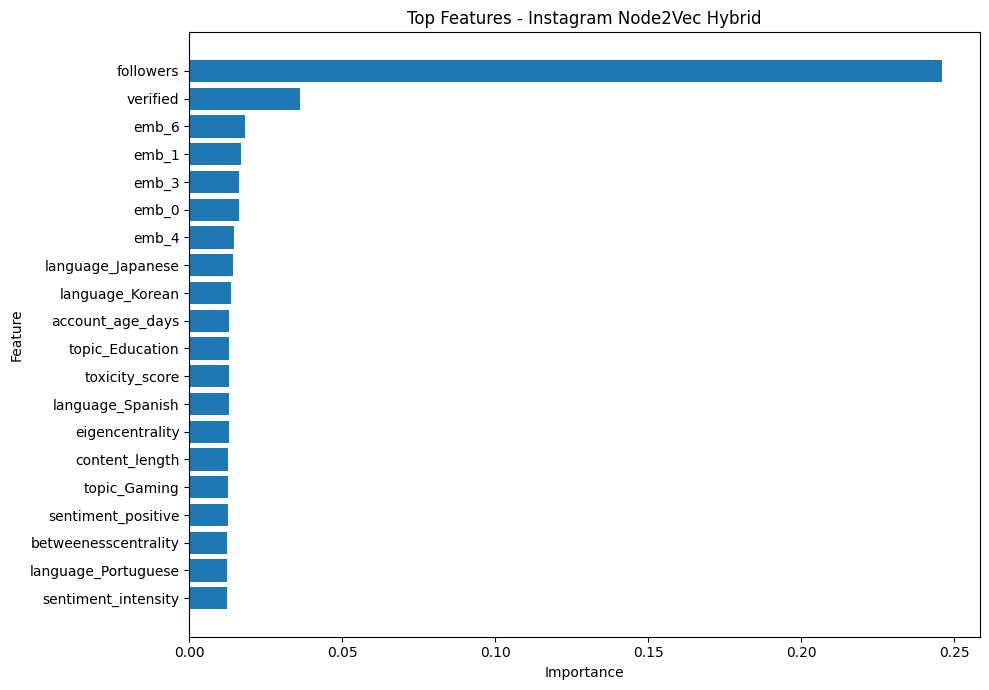

In [ ]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Reddit Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Reddit graph + Node2vector

In [346]:
# 1. Xác định các cột n2v có Importance cao nhất từ kết quả mới của bạn
# Chốt danh sách emb_ xịn (Bà bảo của bà là emb_ nên tui sửa lại hết thành emb_ nha)
selected_n2v = ["emb_0", "emb_6", "emb_3", "emb_4", "emb_1"]

# Chỉ giữ lại post_id và các cột đã chọn để tránh làm nặng model
embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print("--- ✅ Đã lọc Embedding tinh gọn ---")
print(f"Các cột sẽ dùng: {embedding_df_filtered.columns.tolist()}")

--- ✅ Đã lọc Embedding tinh gọn ---
Các cột sẽ dùng: ['post_id', 'emb_0', 'emb_6', 'emb_3', 'emb_4', 'emb_1']


In [347]:
train_df = pd.read_csv(
    "reddit_hybrid_train.csv"
)

test_df = pd.read_csv(
    "reddit_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (30068, 116)
Test Shape : (7517, 116)

NODE2VEC EMBEDDINGS
(37585, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [348]:
# 2. MERGE VÀO DATA HYBRID
# =====================================================
# Merge vào tập Train
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")

# Merge vào tập Test
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")

print(f"\n--- ✅ Đã Merge xong ---")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")


--- ✅ Đã Merge xong ---
Train Shape: (30068, 121) | Test Shape: (7517, 121)


In [349]:
# 3. XỬ LÝ MISSING VALUES (FIX "RÂU ÔNG NỌ" Ở ĐÂY)
# =====================================================
# Bà phải tìm cột bắt đầu bằng "emb_" chứ không phải "n2v_" nè!
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\n🔍 Đang kiểm tra Missing cho {len(actual_emb_cols)} cột embedding...")

# Điền 0 cho những bài post "cô đơn" (không có kết nối graph)
train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing sau khi fill: {train_final[actual_emb_cols].isnull().sum().sum()}")


🔍 Đang kiểm tra Missing cho 5 cột embedding...
Missing sau khi fill: 0


In [350]:
# =====================================================
# 4. DỌN DẸP ID (DROP CÁC CỘT KHÔNG DÙNG ĐỂ TRAIN)
# =====================================================
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"\n--- 🚀 HOÀN TẤT ---")
print(f"Dữ liệu cuối cùng: {train_final.shape[1]} features.")


--- 🚀 HOÀN TẤT ---
Dữ liệu cuối cùng: 119 features.


In [351]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (30068, 118)
X_test : (7517, 118)


In [355]:
# XGBOOST MODEL
# =====================================================

# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.5,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...

Training completed 🚀


In [356]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [358]:


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      5983
           1       0.43      0.76      0.55      1534

    accuracy                           0.75      7517
   macro avg       0.68      0.75      0.69      7517
weighted avg       0.82      0.75      0.77      7517

ROC-AUC  : 0.8413


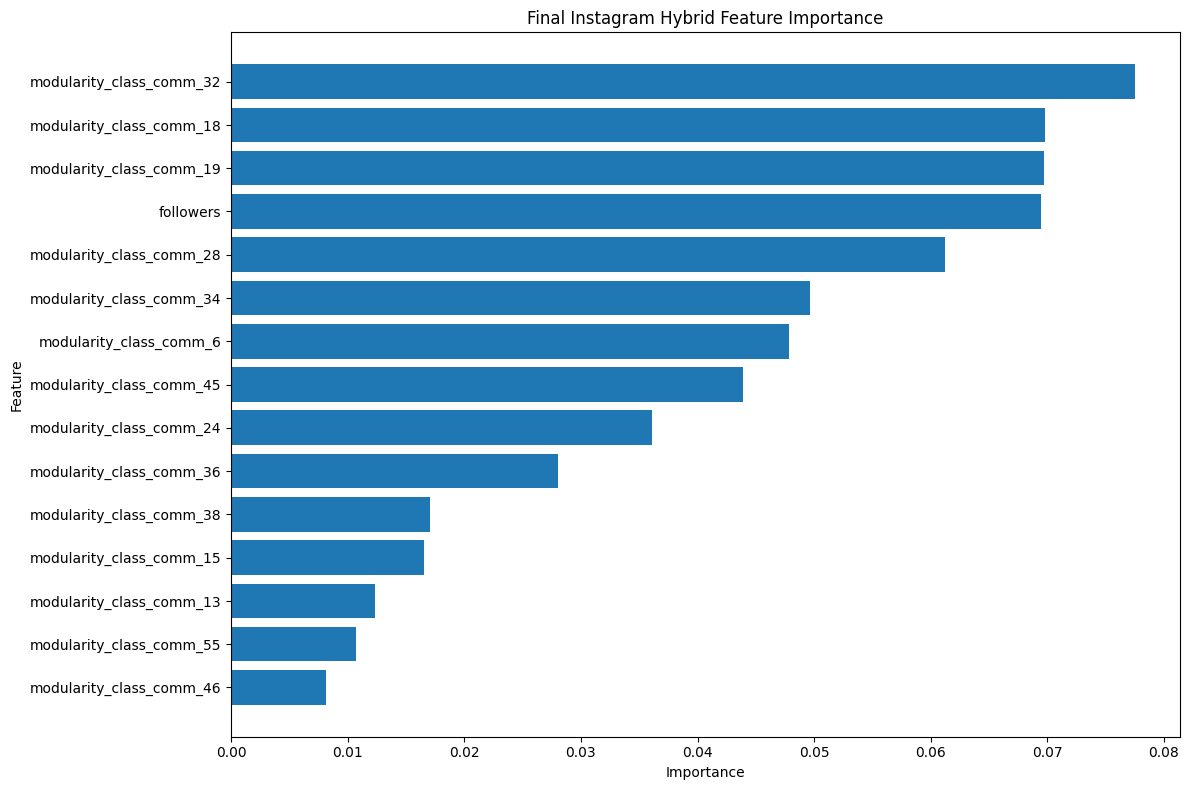

In [359]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Instagram Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()